# task 1

In [1]:
import torch
import torch.nn as nn
from torch import optim
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [8]:
# # 下载并加载 MNIST 训练集
# train_data = datasets.MNIST(
#     root='data',         # 数据集存放路径（如果没有，会自动创建）
#     train=True,          # True 表示加载训练集
#     transform=ToTensor(),# 将 PIL 图像转换为 PyTorch 的张量格式（0~255 → 0~1）
#     download=True,       # 如果本地没有数据集，则从网络下载
# )

# # 加载 MNIST 测试集
# test_data = datasets.MNIST(
#     root='data',         # 数据存放路径，与训练集相同
#     train=False,         # False 表示加载测试集
#     transform=ToTensor() # 同样转换为张量格式
# )

# # 打印训练集的基本信息（样本数量、类型等）
# print(train_data)
# # 打印训练集图像的尺寸（60000 张 28×28 的灰度图）
# print(train_data.data.size())
# # 打印测试集的基本信息
# print(test_data)
# # 打印测试集图像的尺寸（10000 张 28×28 的灰度图）
# print(test_data.data.size())

## Visualization of MNIST dataset

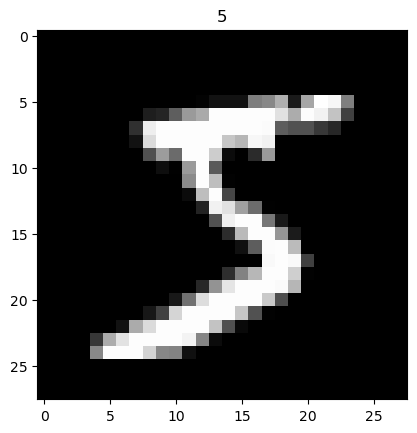

In [4]:
# Visualization of MNIST dataset
# Plot one train_data
plt.imshow(train_data.data[0], cmap='gray')
plt.title('%i' % train_data.targets[0])
plt.show()

## Plot multiple train_data

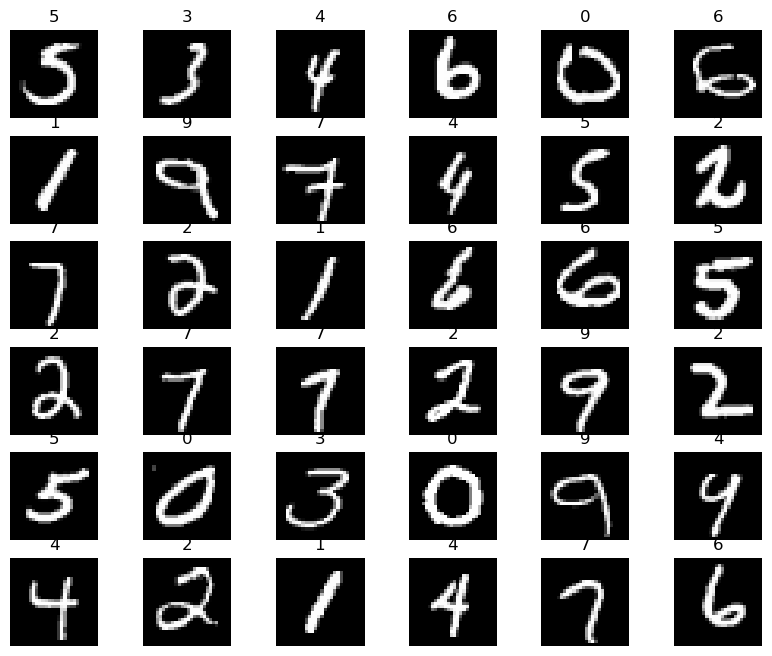

In [7]:
# Plot multiple train_data
figure = plt.figure(figsize=(10, 8))
cols, rows = 6, 6
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

## Preparing data for training with DataLoaders

In [ ]:
# 使用 DataLoader 为训练和测试准备批量数据
loaders = {
    'train': torch.utils.data.DataLoader(
        train_data,       # 训练集
        batch_size=100,   # 每个 batch 取 100 张图片
        shuffle=True,     # 每个 epoch 随机打乱训练数据（很重要）
        num_workers=0     # 数据加载线程数（Windows 推荐 0）
    ),
    
    'test': torch.utils.data.DataLoader(
        test_data,        # 测试集
        batch_size=100,   # 每个 batch 同样取 100 张
        shuffle=True,     # 测试集一般不需要 shuffle，这里写 True 也可以
        num_workers=0
    ),
}

# 打印 DataLoader 的结构信息
print(loaders)

{'train': <torch.utils.data.dataloader.DataLoader object at 0x000001DA83EC6170>, 'test': <torch.utils.data.dataloader.DataLoader object at 0x000001DA83EC5D50>}


In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,      # 输入通道数：1（MNIST 是单通道灰度图）
                out_channels=16,    # 输出通道数：16（卷积核数量 = 提取 16 种特征）
                kernel_size=5,      # 卷积核大小 5×5
                stride=1,           # 步幅 1（像素点逐个滑动）
                padding=2,          # 边缘填充 2，使卷积后图像尺寸保持不变 (28→28)
            ),
            nn.ReLU(),              # 激活函数：引入非线性，提高表达能力
            nn.MaxPool2d(kernel_size=2),  
                                    # 池化层（将图像尺寸减半：28→14） 
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     # 5 * 5 * 16 Kernel * 32 Number
            nn.ReLU(),                      # 14 * 14 * 32
            nn.MaxPool2d(2),   # 14 * 14 * 16 -> 7 * 7 * 32 resize it into half
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10) # 因为我们的研究做的是这个10个数字的分类
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output, x    # return x for visualization

cnn = CNN()
print(cnn)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)


In [11]:
# Define loss function
loss_func = nn.CrossEntropyLoss()   
print(loss_func)

# Define a Optimization Function
optimizer = optim.Adam(cnn.parameters(), lr = 0.01)   
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [14]:
# Train the model
num_epochs = 10

def train(num_epochs, cnn, loaders):
    
    cnn.train()
        
    # Train the model
    total_step = len(loaders['train'])
        
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):

            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)   # batch x
            b_y = Variable(labels)   # batch y

            output = cnn(b_x)[0]               
            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
            loss.backward()
            
            # apply gradients             
            optimizer.step()
            if (i+1) % 100 == 0:
                    print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                        .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

train(num_epochs, cnn, loaders)

Epoch [1/10], Step [100/600], Loss: 0.1873
Epoch [1/10], Step [200/600], Loss: 0.0479
Epoch [1/10], Step [300/600], Loss: 0.0391
Epoch [1/10], Step [400/600], Loss: 0.0740
Epoch [1/10], Step [500/600], Loss: 0.0926
Epoch [1/10], Step [600/600], Loss: 0.1572
Epoch [2/10], Step [100/600], Loss: 0.0312
Epoch [2/10], Step [200/600], Loss: 0.0288
Epoch [2/10], Step [300/600], Loss: 0.1119
Epoch [2/10], Step [400/600], Loss: 0.0554
Epoch [2/10], Step [500/600], Loss: 0.0310
Epoch [2/10], Step [600/600], Loss: 0.0651
Epoch [3/10], Step [100/600], Loss: 0.0110
Epoch [3/10], Step [200/600], Loss: 0.0167
Epoch [3/10], Step [300/600], Loss: 0.0492
Epoch [3/10], Step [400/600], Loss: 0.1201
Epoch [3/10], Step [500/600], Loss: 0.0235
Epoch [3/10], Step [600/600], Loss: 0.0056
Epoch [4/10], Step [100/600], Loss: 0.0257
Epoch [4/10], Step [200/600], Loss: 0.0641
Epoch [4/10], Step [300/600], Loss: 0.0904
Epoch [4/10], Step [400/600], Loss: 0.1060
Epoch [4/10], Step [500/600], Loss: 0.0222
Epoch [4/10

In [16]:
# Evaluate the model on test data
def test():
    # Test the model
    cnn.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in loaders['test']:
            test_output, last_layer = cnn(images)
            pred_y = torch.max(test_output, 1)[1].data.squeeze()
            correct += (pred_y == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    print('Test Accuracy of the model on the 10000 test images: %.4f' % accuracy)

test()

Test Accuracy of the model on the 10000 test images: 0.9842


In [17]:
# Print 10 predictions from test data
sample = next(iter(loaders['test']))
imgs, lbls = sample

actual_number = lbls[:10].numpy()
print(actual_number)

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')

[6 4 1 1 3 2 2 9 5 6]
Prediction number: [6 4 1 1 3 2 2 9 5 6]
Actual number: [6 4 1 1 3 2 2 9 5 6]


## try other epochs

In [19]:
num_epochs=1
train(num_epochs, cnn, loaders)

Epoch [1/1], Step [100/600], Loss: 0.1895
Epoch [1/1], Step [200/600], Loss: 0.0309
Epoch [1/1], Step [300/600], Loss: 0.0807
Epoch [1/1], Step [400/600], Loss: 0.0374
Epoch [1/1], Step [500/600], Loss: 0.0200
Epoch [1/1], Step [600/600], Loss: 0.0667


In [20]:
test()

Test Accuracy of the model on the 10000 test images: 0.9811


In [21]:
# Print 10 predictions from test data
sample = next(iter(loaders['test']))
imgs, lbls = sample

actual_number = lbls[:10].numpy()
print(actual_number)

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')

[3 4 4 2 7 5 9 2 6 4]
Prediction number: [3 4 4 2 7 5 9 2 6 4]
Actual number: [3 4 4 2 7 5 9 2 6 4]


# task 2 

In [22]:
import os
import numpy as np
import torch
from torchvision.io import read_image
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
plt.rcParams["savefig.bbox"] = 'tight'

## read file

In [ ]:
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    plt.show()

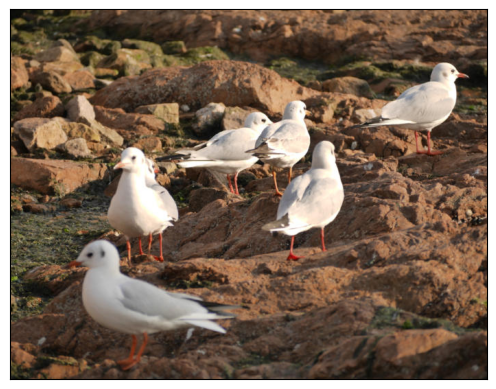

In [70]:
file = r'D:\D盘桌面\bird_5.jpg'
img = read_image(file)
show(img)

In [71]:
## image classification with pretrained ResNet50 (1000 classes)

# Step 1: Initialize model with the best available weights
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)

# Step 4: Use the model and print the predicted category
prediction = model(batch).squeeze(0).softmax(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]
print(f"{category_name}: {100 * score:.1f}%")

redshank: 9.5%


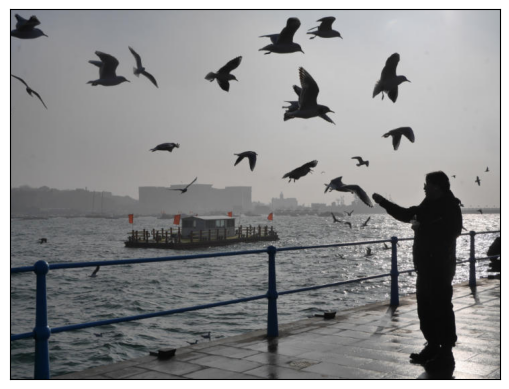

In [62]:
file = r'D:\D盘桌面\bird_6.jpg'
img = read_image(file)
show(img)

## image classification with pretrained ResNet50 (1000 classes)

In [63]:
## image classification with pretrained ResNet50 (1000 classes)

# Step 1: Initialize model with the best available weights
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)

# Step 4: Use the model and print the predicted category
prediction = model(batch).squeeze(0).softmax(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]
print(f"{category_name}: {100 * score:.1f}%")

c:\Users\JUJUBE\anaconda3\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


pelican: 23.8%


## image segmentation with pretrained FCN_ResNet50 (20 classes)

In [64]:
## image segmentation with pretrained FCN_ResNet50 (20 classes)

# Step 1: Initialize model with the best available weights
weights = FCN_ResNet50_Weights.DEFAULT
model = fcn_resnet50(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)

# Step 4: Use the model and visualize the prediction
prediction = model(batch)["out"]
normalized_masks = prediction.softmax(dim=1)
print(normalized_masks.shape)
class_to_idx = {cls: idx for (idx, cls) in enumerate(weights.meta["categories"])}
print(class_to_idx)
mask = normalized_masks[0, class_to_idx["bird"]]
to_pil_image(mask).show()

torch.Size([1, 21, 520, 689])
{'__background__': 0, 'aeroplane': 1, 'bicycle': 2, 'bird': 3, 'boat': 4, 'bottle': 5, 'bus': 6, 'car': 7, 'cat': 8, 'chair': 9, 'cow': 10, 'diningtable': 11, 'dog': 12, 'horse': 13, 'motorbike': 14, 'person': 15, 'pottedplant': 16, 'sheep': 17, 'sofa': 18, 'train': 19, 'tvmonitor': 20}


In [65]:
## object detection with pretrained FasterRCNN_ResNet50 (90 classes)

# Step 1: Initialize model with the best available weights
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = [preprocess(img)]

# Step 4: Use the model and visualize the prediction
prediction = model(batch)[0]
labels = [weights.meta["categories"][i] for i in prediction["labels"]]
box = draw_bounding_boxes(img, boxes=prediction["boxes"],
                          labels=labels,
                          colors="red",
                          width=4, font_size=30)
im = to_pil_image(box.detach())
im.show()

## Instance segmentation with pretrained MaskRCNN_ResNet50 (90 classes)

In [66]:
## Instance segmentation with pretrained MaskRCNN_ResNet50 (90 classes)

# Step 1: Initialize model with the best available weights
weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = maskrcnn_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = [preprocess(img)]

# Step 4: Use the model and visualize the prediction
output = model(batch)
print(output)
bird1_output = output[0]
bird1_masks = bird1_output['masks']
print(f"shape = {bird1_masks.shape}, dtype = {bird1_masks.dtype}, "
      f"min = {bird1_masks.min()}, max = {bird1_masks.max()}")
print("For the first bird, the following instances were detected:")
print([weights.meta["categories"][label] for label in bird1_output['labels']])


[{'boxes': tensor([[539.0565, 239.1676, 674.9388, 545.9813],
        [405.1236,  84.7219, 485.6839, 172.3227],
        [176.2582,  54.0786, 221.0135, 118.3776],
        [331.5426, 210.7415, 369.5291, 241.9467],
        [367.6229,  12.1952, 439.7433,  68.2040],
        [538.3682,  64.3030, 597.7831, 141.0818],
        [440.5699,  11.3918, 494.4888,  44.7505],
        [167.0033, 299.8207, 400.1290, 361.0707],
        [552.7780, 175.0359, 602.1856, 210.3592],
        [289.2798,  69.7460, 345.1747, 124.3673],
        [112.7963,  62.7512, 180.6143, 114.3963],
        [  0.6750,  95.3790,  56.1267, 148.6217],
        [206.7293, 198.4781, 253.8779, 213.6397]], grad_fn=<StackBackward0>), 'labels': tensor([ 1, 16, 16, 16, 16, 16, 16,  9, 16, 16, 16, 16, 16]), 'scores': tensor([0.9976, 0.9909, 0.9848, 0.9820, 0.9783, 0.9764, 0.9718, 0.9650, 0.9530,
        0.9496, 0.9476, 0.9109, 0.9009], grad_fn=<IndexBackward0>), 'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0

In [67]:
print(bird1_output['scores'])

tensor([0.9976, 0.9909, 0.9848, 0.9820, 0.9783, 0.9764, 0.9718, 0.9650, 0.9530,
        0.9496, 0.9476, 0.9109, 0.9009], grad_fn=<IndexBackward0>)


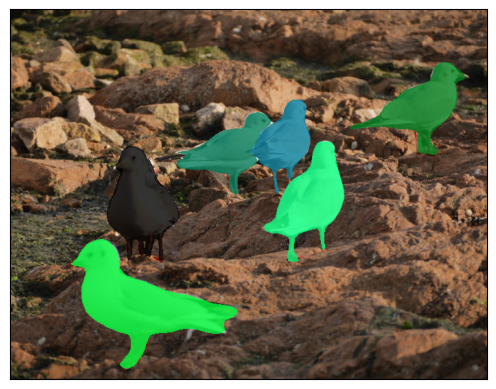

In [57]:
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    plt.show()

proba_threshold = 0.5
score_threshold = .75
# bird1_bool_masks = bird1_output['masks'] > proba_threshold
# print(f"shape = {bird1_bool_masks.shape}, dtype = {bird1_bool_masks.dtype}")
# bird1_bool_masks = bird1_bool_masks.squeeze(1)
# show(draw_segmentation_masks(img, bird1_bool_masks, alpha=0.9))
boolean_masks = [
    out['masks'][out['scores'] > score_threshold] > proba_threshold
    for out in output
]

birds_with_masks = [
    draw_segmentation_masks(img, mask.squeeze(1))
    for img, mask in zip([img], boolean_masks)
]
show(birds_with_masks)

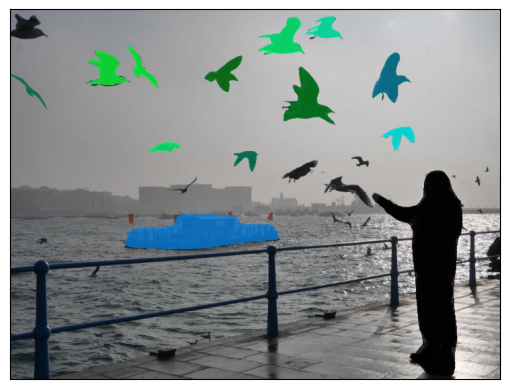

In [68]:
proba_threshold = 0.5
score_threshold = .75
# bird1_bool_masks = bird1_output['masks'] > proba_threshold
# print(f"shape = {bird1_bool_masks.shape}, dtype = {bird1_bool_masks.dtype}")
# bird1_bool_masks = bird1_bool_masks.squeeze(1)
# show(draw_segmentation_masks(img, bird1_bool_masks, alpha=0.9))
boolean_masks = [
    out['masks'][out['scores'] > score_threshold] > proba_threshold
    for out in output
]

birds_with_masks = [
    draw_segmentation_masks(img, mask.squeeze(1))
    for img, mask in zip([img], boolean_masks)
]
show(birds_with_masks)